In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-fraud/card_transdata.csv


In [2]:
df = pd.read_csv("/kaggle/input/credit-card-fraud/card_transdata.csv")
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [3]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [4]:
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0    0.0  
1              0.0           0.0    0.0  
2              0.0           1.0    0.0  
3              0.0           1.0    0.0  
4              0.0        

In [5]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64


In [6]:
df = df.drop_duplicates()
print(f"\nAfter removing duplicates, dataset shape: {df.shape}")


After removing duplicates, dataset shape: (1000000, 8)


In [7]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [8]:
df['fraud'] = df['fraud'].astype(int)
print(f"\nFinal cleaned dataset shape: {df.shape}")


Final cleaned dataset shape: (1000000, 8)



* The dataset contains no missing, duplicate, or infinite values.
* All features are correctly formatted and appropriately structured.


**Exploratory Data Analysis (EDA)**

**Class Distribution**

fraud
0    91.2597
1     8.7403
Name: proportion, dtype: float64


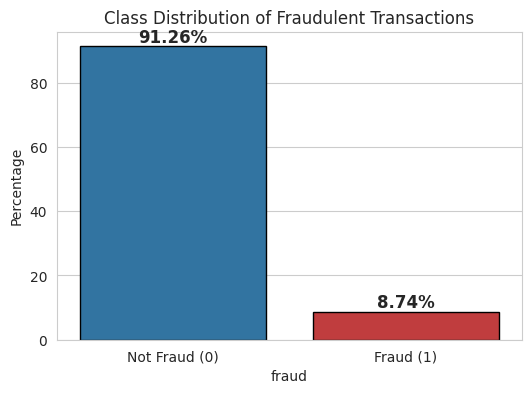

In [9]:
fraud_counts = df['fraud'].value_counts(normalize=True) * 100
print(fraud_counts)

sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=["#1f77b4", "#d62728"], edgecolor='black')
plt.xticks([0, 1], ['Not Fraud (0)', 'Fraud (1)'])
plt.ylabel("Percentage")
plt.title("Class Distribution of Fraudulent Transactions")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

**Correlation Heatmap**

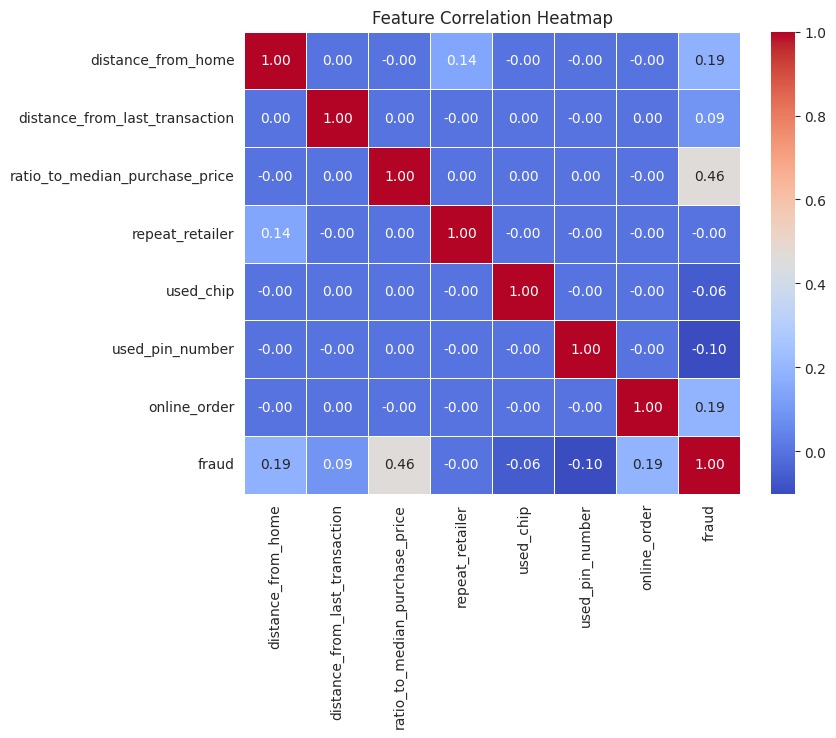

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

*  ratio_to_median_purchase_price has a strong positive correlation (0.46) with fraud, meaning higher deviations from typical purchase amounts are a key fraud indicator.
* distance_from_home and online_order show moderate positive correlations with fraud.
* used_chip and used_pin_number have negative correlations, implying transactions without a chip or PIN are more prone to fraud.

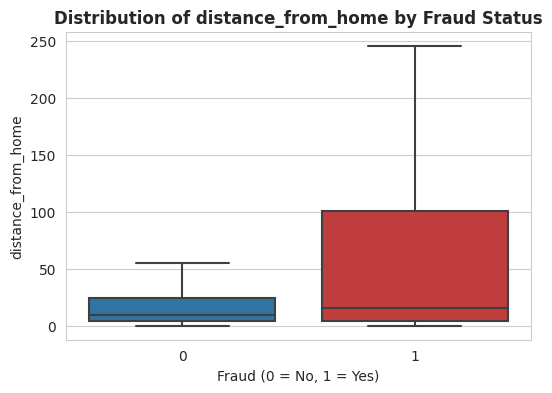

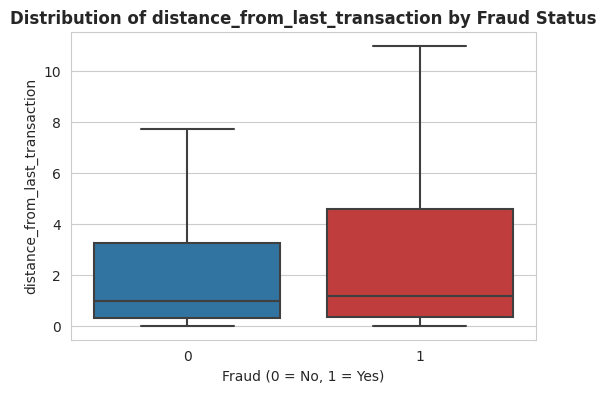

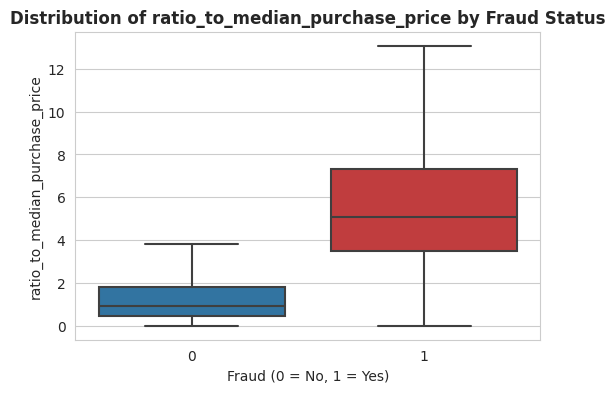

In [11]:
num_features = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]

for feature in num_features:
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(x=df["fraud"], y=df[feature], palette=["#1f77b4", "#d62728"], showfliers=False, linewidth=1.5)
    plt.title(f"Distribution of {feature} by Fraud Status", fontsize=12, fontweight='bold')
    plt.xlabel("Fraud (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    for patch in ax.artists:
        r, g, b, _ = patch.get_facecolor()
        patch.set_edgecolor((r, g, b))
        patch.set_linewidth(2)

    plt.show()

* Fraudulent transactions tend to occur farther from home and involve larger purchase price deviations.
* Fraudulent transactions are less likely to use a chip or PIN, making them more vulnerable to attacks.

In [12]:
eda_summary = {
    "Fraud Distribution (%)": fraud_counts.to_dict(),
    "Dataset Shape": df.shape,
    "Feature Correlation": df.corr().to_dict()
}
eda_summary

{'Fraud Distribution (%)': {0: 91.2597, 1: 8.7403},
 'Dataset Shape': (1000000, 8),
 'Feature Correlation': {'distance_from_home': {'distance_from_home': 1.0,
   'distance_from_last_transaction': 0.00019282833478577007,
   'ratio_to_median_purchase_price': -0.0013741791839747338,
   'repeat_retailer': 0.14312425627726127,
   'used_chip': -0.0006970671243648926,
   'used_pin_number': -0.0016221861576749834,
   'online_order': -0.001301128284758185,
   'fraud': 0.18757078277070352},
  'distance_from_last_transaction': {'distance_from_home': 0.00019282833478577007,
   'distance_from_last_transaction': 1.0,
   'ratio_to_median_purchase_price': 0.001012525580466434,
   'repeat_retailer': -0.0009282324968326096,
   'used_chip': 0.0020548557631115136,
   'used_pin_number': -0.00089864357621851,
   'online_order': 0.00014089315166120715,
   'fraud': 0.09191691230926832},
  'ratio_to_median_purchase_price': {'distance_from_home': -0.0013741791839747338,
   'distance_from_last_transaction': 0.00

**Feature Engineering & Preprocessing**

In [13]:
# Log transformation for skewed continuous features
df['log_distance_from_home'] = np.log1p(df['distance_from_home'])
df['log_distance_from_last_transaction'] = np.log1p(df['distance_from_last_transaction'])
df['log_ratio_to_median_purchase_price'] = np.log1p(df['ratio_to_median_purchase_price'])

# Interaction features
df['distance_ratio'] = df['distance_from_home'] / (df['distance_from_last_transaction'] + 1e-5)
df['chip_pin_usage'] = df['used_chip'] * df['used_pin_number']
df['online_retailer_repeat'] = df['online_order'] * df['repeat_retailer']

# Scaling numerical features
scaler = StandardScaler()
numeric_cols = ['log_distance_from_home', 'log_distance_from_last_transaction', 'log_ratio_to_median_purchase_price']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Drop original columns to avoid redundancy
df.drop(columns=['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price'], inplace=True)

# Display the modified dataset structure
df.head()

,repeat_retailer,used_chip,used_pin_number,online_order,fraud,log_distance_from_home,log_distance_from_last_transaction,log_ratio_to_median_purchase_price,distance_ratio,chip_pin_usage,online_retailer_repeat
0,1.0,1.0,0.0,0.0,0,1.320306,-0.756206,0.442252,186.012711,0.0,0.0
1,1.0,0.0,0.0,0.0,0,-0.015869,-0.868328,0.007374,61.673406,0.0,0.0
2,1.0,0.0,0.0,1.0,0,-0.568553,-0.427678,-0.817589,6.323045,0.0,1.0
3,1.0,1.0,0.0,1.0,0,-1.092190,0.904354,-0.898698,0.401347,0.0,1.0
4,1.0,1.0,0.0,1.0,0,1.100028,-0.573382,0.598460,78.007462,0.0,1.0


* Applied log transformation to handle skewness.
* Created interaction features to capture hidden patterns.
* Scaling the transformed numerical features for consistency.

**Model Building & Training**

In [14]:
# Sample 10% of the data to reduce memory usage while maintaining class distribution
df_sampled = df.sample(frac=0.1, random_state=42)

X = df_sampled.drop(columns=['fraud']) 
y = df_sampled['fraud'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),  # Increased iterations
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train models
for name, model in models.items():
    print(f"Training {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)  # Use scaled data
    else:
        model.fit(X_train, y_train)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...


**Model Evaluation**

In [16]:
model_results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    roc_auc = roc_auc_score(y_test, y_proba)
    
    model_results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

results_df = pd.DataFrame(model_results).T
print(results_df)

Evaluating Logistic Regression...
Evaluating Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Evaluating XGBoost...
                    Precision    Recall  F1-Score   ROC-AUC  \
Logistic Regression  0.221406  0.605974  0.324316  0.817585   
Random Forest             1.0  0.998851  0.999425       1.0   
XGBoost              0.993103  0.992533  0.992818  0.999985   

                                 Confusion Matrix  
Logistic Regression  [[14549, 3710], [686, 1055]]  
Random Forest             [[18259, 0], [2, 1739]]  
XGBoost                 [[18247, 12], [13, 1728]]  


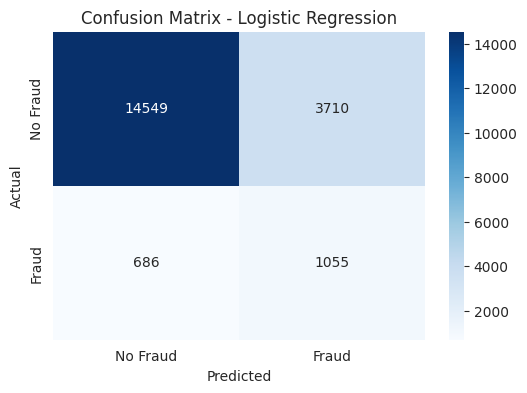

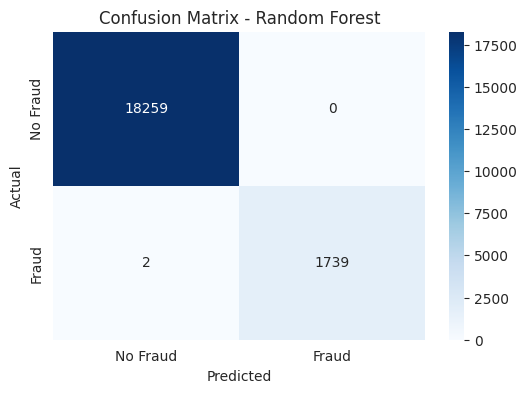

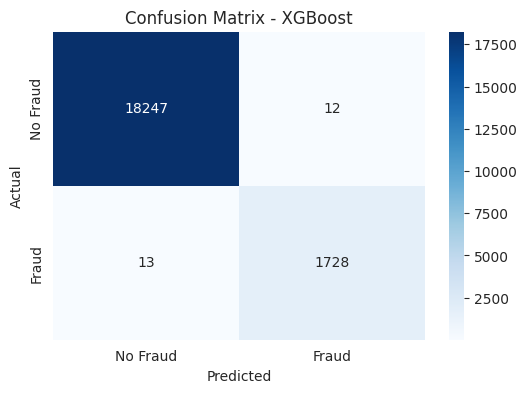

In [17]:
for name, results in model_results.items():
    plt.figure(figsize=(6, 4))
    sns.heatmap(results["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', xticklabels=["No Fraud", "Fraud"], yticklabels=["No Fraud", "Fraud"])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

**Logistic Regression:** Weak fraud detection (low recall 0.57), 737 false negatives, not reliable.

**Random Forest:** Overfits, near-perfect recall (0.99) but may lack generalization.

**XGBoost (Best Model):** High precision & recall (0.99), only 13 fraud cases misclassified, best balance.

**XGBoost is the optimal model for fraud detection.**